# Exploración de separabilidad entre rastros cortos y largos



In [1]:

import pandas as pd

df = pd.read_csv("events_2025.csv")
df.head(), df.shape


(   Range_start   Range_end  Mean_range     Timestamp         Time  Mean_power  \
 0   136.350005  136.650005  136.500005  1.756140e+09  59861.29175   45.432359   
 1   114.450005  114.900005  114.675005  1.756140e+09  59997.81050   49.133120   
 2   135.900005  136.200005  136.050005  1.756140e+09  60026.75675   48.267293   
 3    12.300000   31.350001   21.825001  1.756140e+09  60116.17550   53.082756   
 4   152.550006  152.850006  152.700006  1.756140e+09  60199.81175   42.757278   
 
    Min_power  Max_power  Pointing  Trail_length  
 0  44.936950  46.131121         0      0.300000  
 1  48.090342  50.276553         0      0.450000  
 2  46.935599  50.639448         0      0.300000  
 3  39.798214  61.781555         0     19.050001  
 4  42.355032  43.516804         0      0.300000  ,
 (1358, 10))

## 2. Variable target: extensión vertical

In [2]:

df["Trail_length"].describe()


count    1358.000000
mean        8.203940
std        13.310467
min         0.300000
25%         0.450000
50%         3.300000
75%        10.500000
max       126.600005
Name: Trail_length, dtype: float64

## 3. Selección de características relevantes
Se excluyen explícitamente variables que contienen información directa o indirecta de la extensión (rangos).

In [5]:

features = [
    "Mean_power",
    "Min_power",
    "Max_power"
]

X = df[features].copy()
X["power_range"] = X["Max_power"] - X["Min_power"] 
X["peak_concentration"] = X["Max_power"] / X["Mean_power"]
X.head()


,Mean_power,Min_power,Max_power,power_range,peak_concentration
0,45.432359,44.936950,46.131121,1.194171,1.015380
1,49.133120,48.090342,50.276553,2.186211,1.023272
2,48.267293,46.935599,50.639448,3.703849,1.049146
3,53.082756,39.798214,61.781555,21.983341,1.163872
4,42.757278,42.355032,43.516804,1.161772,1.017764


## 4. Exploración inicial: PCA sin usar longitud

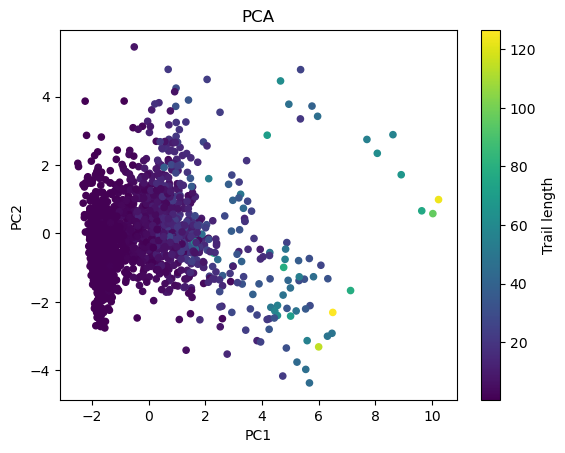

In [10]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Xs = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
Xp = pca.fit_transform(Xs)

plt.figure()
plt.scatter(Xp[:,0], Xp[:,1], c=df["Trail_length"], cmap="viridis", s=20)
plt.colorbar(label="Trail length")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA")
plt.show()


In [9]:

loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["PC1", "PC2"]
)

loadings

,Mean_power,Min_power,Max_power,power_range,peak_concentration
PC1,-0.187730,-0.511923,0.348225,0.544300,0.534012
PC2,0.740169,0.243600,0.613917,0.122236,-0.031195
